# 第31课 · 🎨 随机留下的形状 — PDF、CDF 与交叉熵（cross entropy）损失全可视化

> **🎨 + 模块门闩**：本课用图收束 L27–L30；读图为主。做完后即可进入音频 DSP（L32）。

配合 `s1–s4`，用六张图串联频率收敛、分布形状、标准化、softmax 和交叉熵损失。分类头的 `softmax_cross_entropy` 直觉来自后两张图。

**目标**：用 `matplotlib` 画出六张图——大数定律收敛曲线、均匀/正态 PDF 对比、高斯钟形 + 标准差区间、z-score 前后对比、softmax 柱状、交叉熵损失曲面——以及 Shannon 熵和 CDF 的手写可视化（Visualization）。

**为什么对 Aurora 重要**：分类头 `softmax_cross_entropy` 的数学直觉来自后两张图；Shannon 熵曲线解释了为什么最小化交叉熵等价于最小化 KL 散度；CDF 图对应特征归一化（normalization）的概率解释。

← **上一课**　[L30 · Softmax 与交叉熵](L30_softmax_crossentropy.ipynb)

> 上节课学习了 **Softmax 与交叉熵**：分类模型的输出层与损失函数，手推梯度。  
> 本课将探讨 **概率分布可视化**。

## 本课剧情：让随机留下形状

单次随机事件是噪声，大量重复后频率收敛到概率，样本（Sample）积累成可辨认的分布形状。这节课把这条链的每一步画出来：大数定律（Law of Large Numbers，LLN）的收敛曲线、正态分布（Normal Distribution）的标准差（Standard Deviation，SD）区间、z-score 标准化前后的对比，以及 softmax 把原始分数压成概率再由交叉熵量化为损失的过程。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
from sviz import (style, law_of_large_numbers, dist_compare,
                  gaussian, zscore_demo, softmax_bars, cross_entropy_curve)
style(); print('sviz 就绪')

sviz 就绪


## 实验入口：概率量如何从样本里出现

观察两个控制变量：`n`（样本数）决定频率估计的稳定性，`sigma`（标准差）决定分布的宽窄。调大 `n`，频率曲线收敛更快；调大 `sigma`，钟形曲线铺宽、峰值下降。

## 动手观察：随机代码要多试几次

固定种子运行一次，记录 `n=100` 时的频率估计；再把 `n` 改成 `10000`，比较两次结果与真实概率 1/6 的偏差大小。

In [3]:
import numpy as np

rng = np.random.default_rng(0)
for n in [10, 100, 10_000]:
    rolls = rng.integers(1, 7, size=n)
    estimate = np.mean(rolls == 6)
    print(f'n={n:5d}  频率估计={estimate:.4f}  (理论值 1/6≈0.1667)')


n=   10  频率估计=0.1000  (理论值 1/6≈0.1667)
n=  100  频率估计=0.1600  (理论值 1/6≈0.1667)
n=10000  频率估计=0.1689  (理论值 1/6≈0.1667)


## 代码实验：多次重复同一个随机实验

这个实验展示样本量对频率波动的压制效果：`n` 每增大 10 倍，多次运行之间的估计方差（Variance）大约缩小 10 倍。

In [4]:
import numpy as np

# 大数定律：重复5次实验，观察频率估计的波动随n收窄
for n in [20, 200, 2000]:
    estimates = []
    for seed in range(5):
        rng = np.random.default_rng(seed)
        rolls = rng.integers(1, 7, size=n)
        estimates.append(np.mean(rolls == 6))
    spread = max(estimates) - min(estimates)
    print(f'n={n:4d}  5次估计={np.round(estimates, 3)}  极差={spread:.4f}')


n=  20  5次估计=[0.2  0.15 0.15 0.05 0.3 ]  极差=0.2500
n= 200  5次估计=[0.21  0.18  0.155 0.16  0.21 ]  极差=0.0550
n=2000  5次估计=[0.174 0.184 0.17  0.158 0.176]  极差=0.0250


## 1. 大数定律：频率收敛到概率（对应 s1）

六张图从左到右构成一条认知链：频率收敛（图 1）说明概率可以从重复实验中估计；分布形状（图 2–3）刻画数据的统计结构；z-score 标准化（图 4）把不同尺度的特征统一量纲；softmax（图 5）把原始分数映射为合法概率；交叉熵（图 6）把预测概率与真实标签的差距量化为可微损失。这条链就是 ML 模型从原始数据到训练信号的数学骨架——每张图对应训练流水线的一个节点，少了任何一步，后面的计算就没意义了。

## 1a. 手写 LLN 收敛曲线（`np.cumsum`）

大数定律收敛曲线的核心公式只需一行：`running = np.cumsum(flips) / np.arange(1, n+1)`。
`np.cumsum` 把每次抛掷的结果（0/1）前缀求和，除以当前次数即得运行平均值（Running Mean）。
sviz 内部用的正是同一个公式——下面先显式写出，再用 sviz 画完整图。

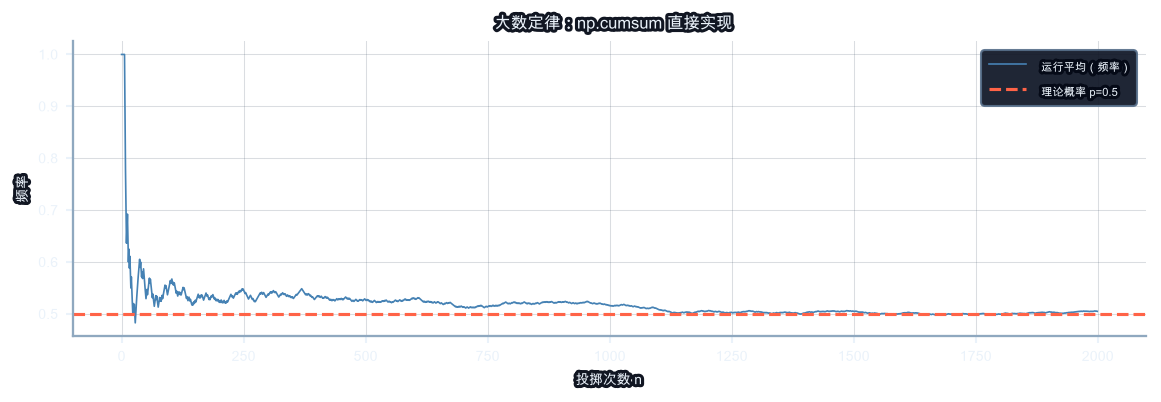

In [5]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
n = 2000
flips = rng.integers(0, 2, size=n)  # 公平硬币：0=反，1=正

# 一行写出 LLN 运行平均
running = np.cumsum(flips) / np.arange(1, n + 1)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(running, color='steelblue', lw=0.8, label='运行平均（频率）')
ax.axhline(0.5, color='tomato', lw=1.5, ls='--', label='理论概率 p=0.5')
ax.set_xlabel('投掷次数 n'); ax.set_ylabel('频率'); ax.legend()
ax.set_title('大数定律：np.cumsum 直接实现')
plt.tight_layout(); plt.show()

# 验证：到 n=2000 时偏差应 < 5%
assert abs(running[-1] - 0.5) < 0.05, f'频率偏差过大: {running[-1]:.4f}'

### 细节：为什么是 `np.arange(1, n+1)` 而不是 `np.arange(n)`？

很多初学者看到 `running = np.cumsum(flips) / np.arange(1, n + 1)` 会想：为什么不是 `np.arange(n)`？

**数值上的差异**：
- `np.arange(n)` 产生 `[0, 1, 2, ..., n-1]`——第一个元素是 **0**
- `np.arange(1, n+1)` 产生 `[1, 2, 3, ..., n]`——全是正整数

**实际后果**：
```python
flips = np.array([1, 0, 1])
cumsum = np.cumsum(flips)  # [1, 1, 2]

# 错误写法
cumsum / np.arange(3)      # [1, 1, 2] / [0, 1, 2] → [inf, 1.0, 1.0] ❌ 第一个数爆炸！

# 正确写法
cumsum / np.arange(1, 4)   # [1, 1, 2] / [1, 2, 3] → [1.0, 0.5, 0.67] ✓
```

**数学逻辑**：运行平均要计算"第 i 次后的平均值"，即前 i 个数之和除以 i。
- 第 1 次：[1] / 1 = 1.0
- 第 2 次：[1+0] / 2 = 0.5
- 第 3 次：[1+0+1] / 3 ≈ 0.67

因为 i 从 1 开始，分母必须是 `[1, 2, 3, ...]` 才对。`np.arange(n)` 从 0 开始，会在第一项触发"除以 0"错误。

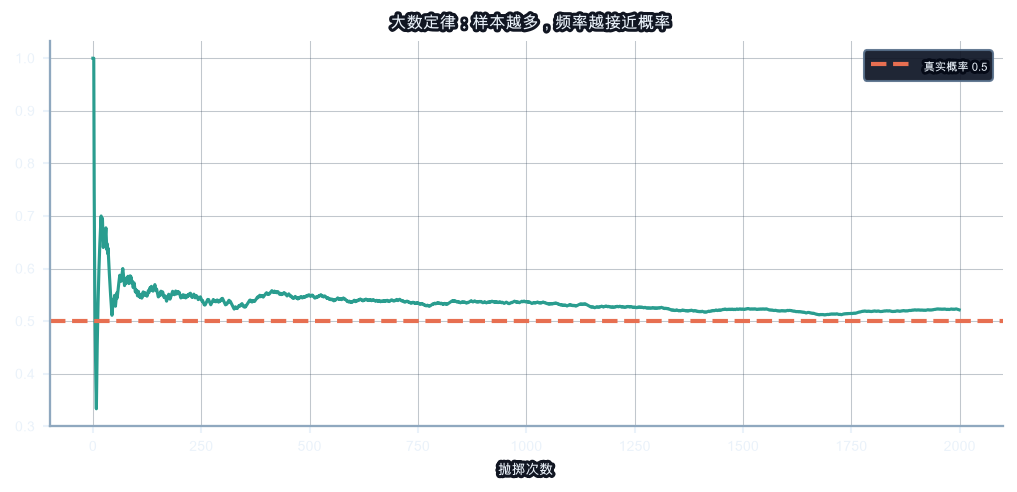

In [6]:
law_of_large_numbers();

## 2. 均匀分布（Uniform Distribution） vs 正态分布（对应 s3）

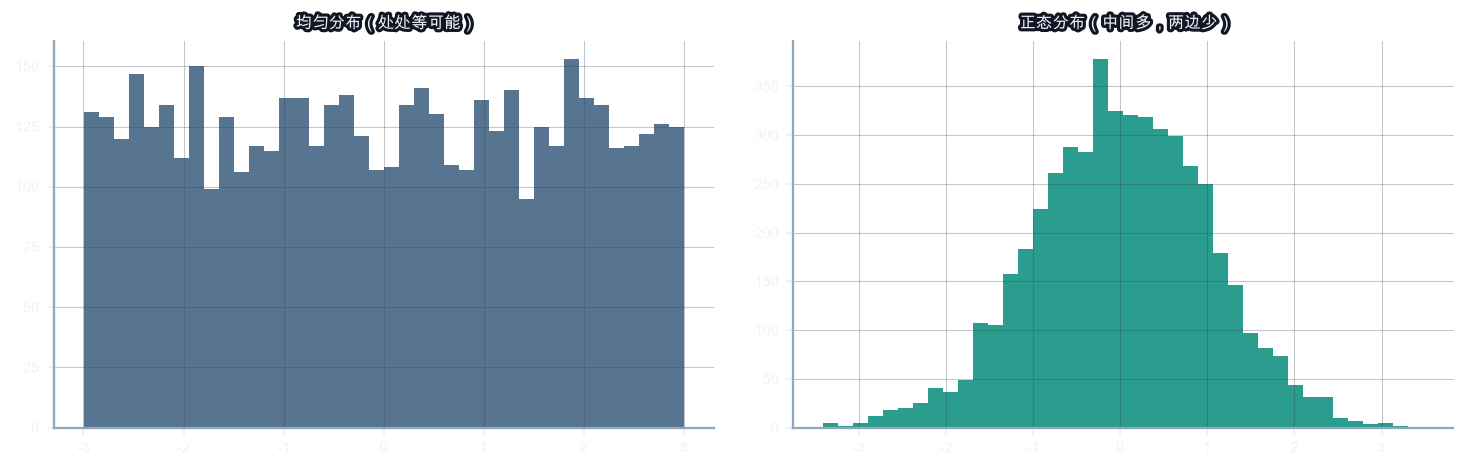

In [7]:
dist_compare();

## 3. 高斯钟形 + 标准差区间（对应 s3）

### 标准差σ的几何意义：钟形的"宽度参数"

标准差是衡量数据"散布程度"的量。正态分布的标准差σ 直接控制钟形曲线的宽窄。

**从公式看**：
$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

当σ增大时：
- 指数中的 $(x-\mu)^2/\sigma^2$ 变小（衰减变缓）
- 曲线变得更"平"、更"宽"
- 前面的系数 $1/(\sigma\sqrt{2\pi})$ 变小（高度降低）

当σ减小时：
- 指数中的 $(x-\mu)^2/\sigma^2$ 变大（衰减变快）
- 曲线变得更"尖"、更"窄"
- 前面的系数变大（高度升高）

**68-95-99.7 法则的几何含义**：
- ±1σ 之间的面积 = 68%（中间的"山腰"部分）
- ±2σ 之间的面积 = 95%（大部分数据集中在这里）
- ±3σ 之间的面积 = 99.7%（几乎全部数据）

这三个数字来自数学积分，是正态分布本身决定的，不是随意选的。

**z-score 的作用**：
$$z = \frac{x - \mu}{\sigma}$$

这个变换做了什么？
- 先减 μ：把曲线的中心移到 0
- 再除 σ：把"宽度"缩放到标准刻度

变换后所有正态分布（不管原来的μ和σ）都变成"标准正态分布"（μ=0, σ=1）。这样任何正态分布都能用同一套 68-95-99.7 的标准来理解。

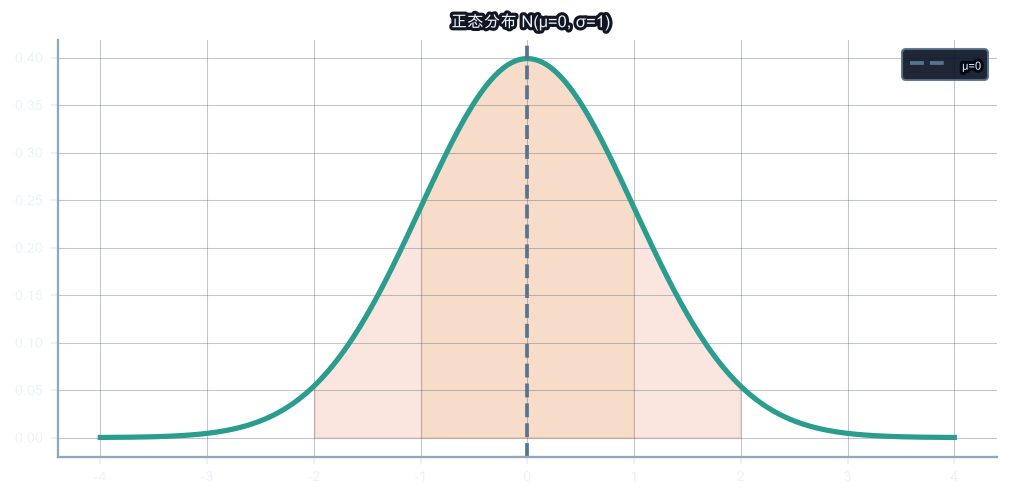

In [8]:
gaussian(0, 1);

## 4. z-score 标准化前后（对应 s2）

**🔗 Aurora**：特征喂入模型前必须标准化。Aurora 训练循环里的 `normalize_features` 对每个维度减均值（Mean）、除标准差；若跳过这步，不同频带的量级差距会让梯度（Gradient）在高能维度过大、在低能维度接近零，导致学习率无法在各层之间对齐，训练不稳定。实现位于 `src/aurora/audio/transforms.py`（`aurora.audio.normalize_features`）。

#### 为什么标准化能"让梯度对齐"？具体的梯度失衡案例

在 Aurora 音频模型中，输入特征来自不同的频带，量级差距巨大。比如低频段的能量可能是 1000，高频段可能是 0.01，这会直接影响神经网络梯度的大小。

**梯度失衡的机制**：
神经网络的损失函数对输入的梯度大小与输入值成正比。假设模型的某一层输出是 `y = w·x + b`，那么：
$$\frac{\partial L}{\partial x} = w \cdot \frac{\partial L}{\partial y}$$

如果 `x` 很大，梯度相对较小（不够敏感）；如果 `x` 很小，梯度会被放大。这导致：
- 高能量维度（如低频）：梯度很小，权重 w 更新缓慢
- 低能量维度（如高频）：梯度很大，权重 w 振荡剧烈

训练不稳定，学习率难以对齐。

**标准化的修复**：
$$z = \frac{x - \mu}{\sigma}$$
把所有特征变换到均值 0、标准差 1 的"标准尺度"。现在：
- 所有特征都在 −3~3 范围内（68-95-99.7 规则）
- 梯度大小被同一标度归一化
- 一个统一的学习率对所有维度都适用

```python
# 对比
x = np.array([1000.0, 0.01])   # 数值差异 10⁵ 倍
z = (x - x.mean()) / x.std()   # [-0.707, 0.707]，现在数值接近
```

下面的对比图会直观展示这个转变。

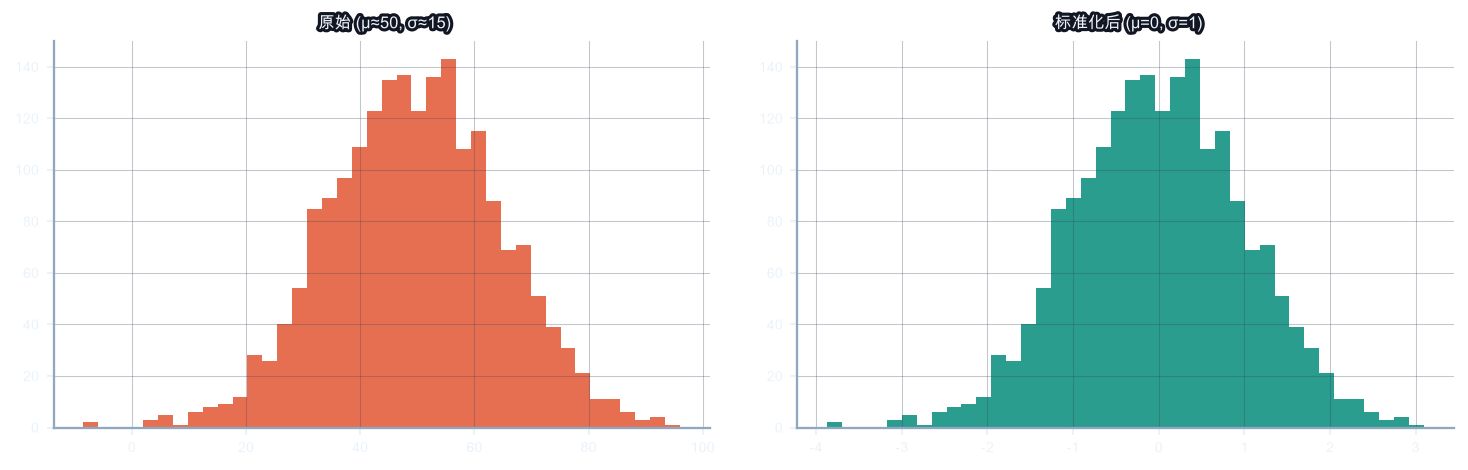

In [9]:
zscore_demo();

## 5. softmax：分数 → 概率（对应 s4）

**🔗 Aurora**：分类头的 `softmax_cross_entropy` 把最后一层的 logit 向量先过 softmax 转为合法概率分布（各维非负、和为 1），再对真实类别取负对数得到损失。两步合并用 log-sum-exp 技巧计算，避免 `np.exp(logit)` 在大数值下溢出。实现位于 `src/aurora/llm/sample.py`（`aurora.llm.softmax_cross_entropy`）。

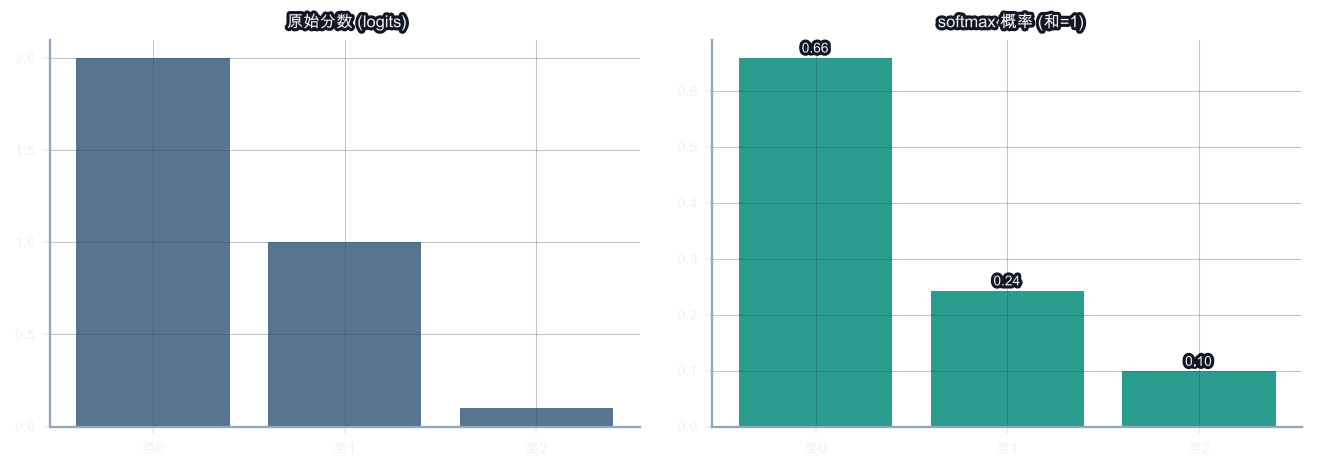

In [10]:
softmax_bars((2.0, 1.0, 0.1));

### 关键技巧：softmax 数值稳定性——为什么减去最大值？

计算 softmax 时，朴素的定义会遇到数值溢出的灾难：
$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

**问题**：当 z 中有很大的数（比如 100），`np.exp(100)` 会远超浮点数的上限，返回 `inf`。

**解决方案**：用一个数学技巧——减去最大值 `c = max(z)`：
$$\text{softmax}(z_i) = \frac{e^{z_i - c}}{\sum_j e^{z_j - c}}$$

**为什么这样不改变结果？** 因为指数的性质：
$$e^{z_i - c} = \frac{e^{z_i}}{e^c}$$

所以分子分母都同时除以 $e^c$，比值不变——这是等价变换。

**例子**：
```
z = [100, 101, 102]
直接算：softmax 用 exp(100), exp(101), exp(102) → inf（溢出）
减去 max：z' = [100-102, 101-102, 102-102] = [-2, -1, 0]
         softmax 用 exp(-2), exp(-1), exp(0) ≈ [0.0900, 0.2447, 0.6652]（安全）
```

**一般规则**：在任何涉及 `exp` 的数值计算里，先减去输入的最大值再计算，能避免溢出。这叫 **log-sum-exp 技巧**，在 softmax、cross entropy、LSTM 等地方都用到。

## 6. 交叉熵：越自信且正确，损失越小（对应 s4）

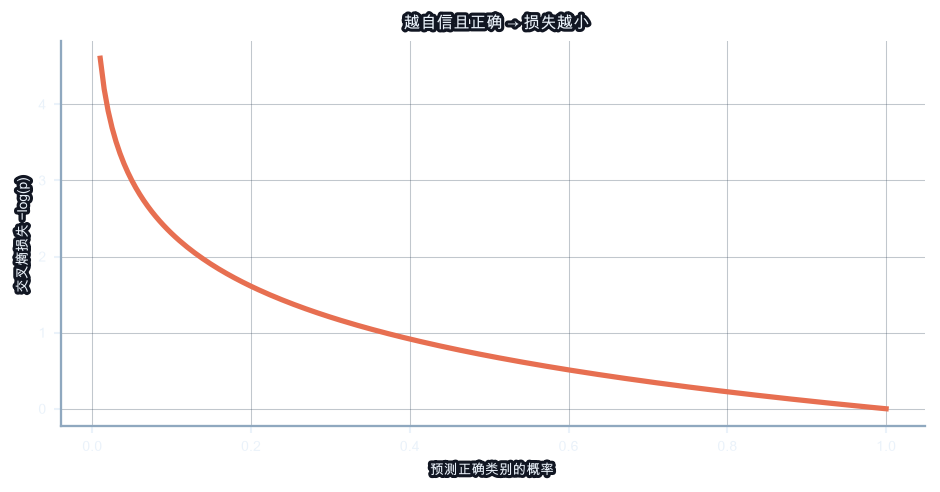

In [11]:
cross_entropy_curve();

## 7. 信息熵（Shannon Entropy）可视化 — 不确定性的形状

Shannon 熵 H(p) = −Σ pᵢ log₂ pᵢ 衡量一个概率分布"有多不确定"。  
两张图分别展示：
- **左图**：二元分布的 H(p) 随 p 变化的曲线——p=0.5 时最大（1 bit），p→0 或 p→1 时趋于 0
- **右图**：自熵 H(p) 与交叉熵 H(p,q) 的对比——H(p,q) = H(p) + KL(p‖q) ≥ H(p)，最小化交叉熵等价于最小化 KL 散度

### 为什么是 Shannon 熵？从生活直觉到公式

想象你在赌场玩轮盘。轮盘有几种设置：

| 情况 | 概率分布 | 你的感受 |
|------|---------|--------|
| 概率=[1, 0, 0, ...] | 已确定结果 | 完全没有悬念（不确定性=0） |
| 概率=[0.5, 0.5] | 硬币：正反各50% | 挺有悬念 |
| 概率=[0.25, 0.25, 0.25, 0.25] | 骰子：6面各1/6 | 悬念更多 |

**不确定性的定量化**：如果事件"惊喜"，说明它发生的概率小。惊喜程度用 −log₂(p) 来衡量：
- p=1（确定）：−log₂(1) = 0（无悬念）
- p=0.5（50%概率）：−log₂(0.5) = 1 bit（1 bit 的信息量）
- p=0.25（25%概率）：−log₂(0.25) = 2 bits（更惊喜）

**Shannon 熵 = 平均惊喜度**：
$$H(p) = -\sum_{i} p_i \log_2 p_i = \mathbb{E}[-\log_2(p_i)]$$

不是某一次的惊喜，而是**多次实验后的平均惊喜值**。

- 确定性分布 [1, 0, ...]：每次都无悬念，平均 H = 0
- 均匀二元分布 [0.5, 0.5]：平均 H = 1 bit
- 均匀 N 元分布 [1/N, ..., 1/N]：平均 H = log₂(N) bits

**为什么用 log₂ 而不是 ln？** 
因为信息论常用"bit"作单位。1 bit = 一个二元选择（是/否、0/1）提供的信息量。log₂ 的底对应二元选择，所以自然选 log₂。如果用 ln，单位就变成"nat"（自然对数单位）。

---

### 处理 0 log 0 = 0 的极限

在计算 H(p) = −Σ pᵢ log₂ pᵢ 时，如果某个分量 pᵢ = 0（这个事件永不发生），那么 pᵢ log₂ pᵢ 会出现"0 × (−∞)"的不定式。数学上我们定义这一项为 0，原因是极限：

$$\lim_{p \to 0^+} p \log_2 p = 0$$

**为什么这个极限是 0？** 用洛必达法则：
$$\lim_{p \to 0^+} p \log_2 p = \lim_{p \to 0^+} \frac{\log_2 p}{1/p} = \lim_{p \to 0^+} \frac{1/(p \ln 2)}{-1/p^2} = \lim_{p \to 0^+} \frac{-p}{\ln 2} = 0$$

直觉上：虽然 log₂(p) → −∞，但前面的 p 以更快的速度趋向 0，乘积最后还是 0。

概率为 0 的事件根本不会发生，对熵的贡献也是 0，这在逻辑上完美一致。

## 练习：手写 `shannon_entropy(p)`

根据公式 **H(p) = −Σ pᵢ log₂ pᵢ**，实现下面的函数。

提示：
- 用 `np.where` 或布尔掩码跳过 pᵢ = 0 的项（0 log 0 定义为 0）。
- 返回值的单位是 **bit**（以 log₂ 为底）。
- 完成后下方断言应全部通过。

In [12]:
import numpy as np

def shannon_entropy(p: np.ndarray) -> float:
    """计算离散概率分布 p 的 Shannon 熵（单位：bit）。

    参数
    ----
    p : array-like，各分量非负且和为 1

    返回
    ----
    float  熵值 ≥ 0，均匀分布时最大，确定性分布时为 0
    """
    # ── 在这里填写你的实现 ──────────────────────────────────
    raise NotImplementedError('请实现 shannon_entropy')
    # ────────────────────────────────────────────────────────


# ── 验证区 ──────────────────────────────────────────────────────────────
try:
    # 确定性分布：熵应为 0
    h0 = shannon_entropy(np.array([1.0, 0.0, 0.0]))
    assert abs(h0) < 1e-9, f'确定性分布熵应为 0，得到 {h0:.6f}'

    # 均匀二元分布：熵应为 1 bit
    h1 = shannon_entropy(np.array([0.5, 0.5]))
    assert abs(h1 - 1.0) < 1e-9, f'均匀二元分布熵应为 1.0 bit，得到 {h1:.6f}'

    # 均匀四元分布：熵应为 2 bit
    h2 = shannon_entropy(np.array([0.25, 0.25, 0.25, 0.25]))
    assert abs(h2 - 2.0) < 1e-9, f'均匀四元分布熵应为 2.0 bit，得到 {h2:.6f}'

    print('✓ 全部断言通过！你的 shannon_entropy 实现正确。')
except (NotImplementedError, TypeError):
    print('⚠ 尚未实现——请填写函数体后重新运行。')


⚠ 尚未实现——请填写函数体后重新运行。


H(p)=1.1568  H(p,q_好)=1.1672  H(p,q_差)=3.0219
✅ H(p,q) ≥ H(p) 验证通过


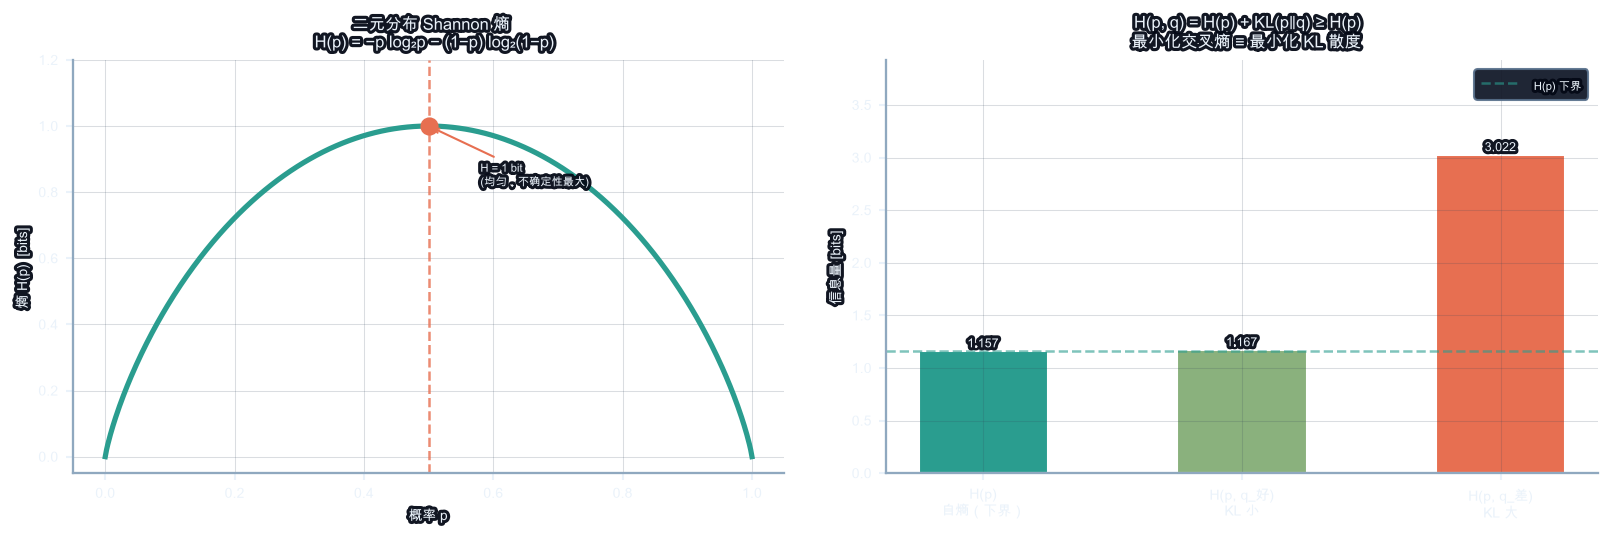

In [13]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# ── 左图：二元分布 H(p) 曲线 ─────────────────────────────────────────────
p = np.linspace(1e-9, 1 - 1e-9, 500)
H = -p * np.log2(p) - (1 - p) * np.log2(1 - p)

ax1.plot(p, H, color='#2A9D8F', lw=2.5)
ax1.axvline(0.5, color='#E76F51', lw=1.2, ls='--', alpha=0.8)
ax1.scatter([0.5], [1.0], s=60, color='#E76F51', zorder=5)
ax1.annotate('H = 1 bit\n(均匀，不确定性最大)', (0.5, 1.0),
             xytext=(0.58, 0.82), fontsize=9,
             arrowprops=dict(arrowstyle='->', color='#E76F51'))
ax1.set_xlabel('概率 p')
ax1.set_ylabel('熵 H(p)  [bits]')
ax1.set_title('二元分布 Shannon 熵\nH(p) = −p log₂p − (1−p) log₂(1−p)')
ax1.set_ylim(-0.05, 1.2)

# ── 右图：自熵 vs 交叉熵柱状对比 ─────────────────────────────────────────
def h_bits(p):
    p = np.asarray(p, float)
    return float(-np.sum(p[p > 0] * np.log2(p[p > 0])))

def hpq_bits(p, q):
    p = np.asarray(p, float)
    q = np.clip(np.asarray(q, float), 1e-15, None)
    return float(-np.sum(p * np.log2(q)))

p_true = np.array([0.7, 0.2, 0.1])
q_good = np.array([0.65, 0.25, 0.10])
q_bad  = np.array([0.10, 0.10, 0.80])

labels = ['H(p)\n自熵（下界）', 'H(p, q_好)\nKL 小', 'H(p, q_差)\nKL 大']
vals   = [h_bits(p_true), hpq_bits(p_true, q_good), hpq_bits(p_true, q_bad)]
colors = ['#2A9D8F', '#8AB17D', '#E76F51']

bars = ax2.bar(labels, vals, color=colors, edgecolor='white', width=0.5)
for bar, v in zip(bars, vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 0.04,
             f'{v:.3f}', ha='center', fontsize=10)
ax2.axhline(vals[0], color='#2A9D8F', ls='--', lw=1.2, alpha=0.6, label='H(p) 下界')
ax2.set_ylabel('信息量 [bits]')
ax2.set_title('H(p, q) = H(p) + KL(p‖q) ≥ H(p)\n最小化交叉熵 ≡ 最小化 KL 散度')
ax2.legend(fontsize=9)
ax2.set_ylim(0, max(vals) * 1.3)

plt.tight_layout()
plt.show()

print(f'H(p)={vals[0]:.4f}  H(p,q_好)={vals[1]:.4f}  H(p,q_差)={vals[2]:.4f}')
assert vals[1] >= vals[0] - 1e-9 and vals[2] >= vals[0] - 1e-9
print('✅ H(p,q) ≥ H(p) 验证通过')

---

### 补充：KL 散度的定义与几何含义

交叉熵的公式 H(p,q) = H(p) + KL(p‖q) 里出现了 KL(p‖q)，这是什么？

**KL 散度的定义**：
$$\text{KL}(p \| q) = \sum_{i} p_i \log_2 \frac{p_i}{q_i} = \sum_{i} p_i (\log_2 p_i - \log_2 q_i)$$

（也写成 $\sum p_i \ln(p_i / q_i)$ 当用自然对数时）

**几何含义**：KL 散度衡量两个概率分布有多"不同"。
- KL(p‖q) = 0 当且仅当 p = q（完全相同）
- KL(p‖q) > 0 当 p ≠ q（一定程度的差异）
- KL(p‖q) 越大，分布差异越明显

**为什么这个公式能衡量"距离"？** 
KL 散度来自信息论：假设真实分布是 p，但我们用错误的分布 q 来编码，那么平均浪费的额外比特数就是 KL(p‖q)。

**与交叉熵的关系**：
$$H(p, q) = -\sum_i p_i \log_2 q_i = -\sum_i p_i \log_2 p_i - \sum_i p_i (\log_2 q_i - \log_2 p_i)$$
$$= H(p) + \text{KL}(p \| q)$$

所以最小化交叉熵等价于最小化 KL 散度（因为 H(p) 固定，是真实标签的熵，不可改变）。

**为什么 KL 不对称**？
- KL(p‖q)：真实分布是 p，模型分布是 q → 重视 p 中概率大的事件
- KL(q‖p)：反过来 → 重视 q 中概率大的事件

在分类任务中，我们用 KL(p‖q)（p 是真实标签，q 是模型预测），这样当模型把真实类别的概率搞错时，损失很大。

## 8. 累积分布函数（CDF）可视化 — Φ(x) = P(X ≤ x)

CDF 是 PDF 从 −∞ 到 x 的积分，完整描述"随机变量不超过某值的概率"。  
这里用数值积分（梯形法）计算标准正态 CDF Φ(x)——与 L29 的 `normal_cdf` 相同的原理，加上可视化。

> **68–95–99.7 经验法则**：Φ(1)−Φ(−1) ≈ 68%，Φ(2)−Φ(−2) ≈ 95%，Φ(3)−Φ(−3) ≈ 99.7%

### 梯形法数值积分的工作原理与精度分析

计算 CDF Φ(x) = ∫_{−∞}^{x} f(t) dt 时，不能直接用解析公式，必须用数值积分。这里用**梯形法则**（Trapezoidal Rule）。

**梯形法怎样工作**：
把曲线分成很多小的区间，每个区间用一个梯形近似：
$$\int_a^b f(t) dt \approx \sum_{i=0}^{n-1} \frac{f(x_i) + f(x_{i+1})}{2} \cdot \Delta x$$

其中 $\Delta x$ 是相邻采样点的间距。

**例子**：
```
f(t) 在 [0, 2] 上的积分：
采样点：x = [0, 1, 2]，f(x) = [1, 2, 5]，Δx = 1
面积 ≈ (1+2)/2 × 1 + (2+5)/2 × 1 = 1.5 + 3.5 = 5.0
```

---

### 代码参数的选择原理

在 `normal_cdf` 里用的参数：
```python
def normal_cdf(x_eval, mu=0.0, sigma=1.0, n=4000):
    xs  = np.linspace(mu - 6 * sigma, x_eval, n)
    return float(np.trapezoid(gaussian_pdf(xs, mu, sigma), xs))
```

**为什么从 `mu - 6*sigma` 开始，而不是 −∞？**
- 理论上 PDF 的积分范围是 −∞ 到 +∞
- 但正态分布的值在 ±6σ 外已经极小（小于 10⁻¹⁰）
- 实际上不积分这部分误差很小

**68-95-99.7 规则的精确数值**：
$$P(|X - \mu| \leq \sigma) \approx 0.6827$$
$$P(|X - \mu| \leq 2\sigma) \approx 0.9545$$
$$P(|X - \mu| \leq 3\sigma) \approx 0.9973$$

从 −6σ 到 6σ 已经涵盖了超过 99.99% 的概率，剩余误差不足 0.01%。

**为什么用 n=4000 个采样点？**
- 梯形法的误差随 n 的平方反比递减：误差 ∝ 1/n²
- 在 [−6σ, 6σ] 上用 4000 个点，间距 Δx ≈ 0.003，精度足以达到 10⁻⁶
- 对于 68-95-99.7 的验证来说足够精确

**如何判断精度足够？**
一个简单的验证：多次运行看积分结果是否稳定，或改变 n 值看结果是否变化（比如 n=2000 vs n=4000）。下面会演示。

±1σ: 0.6827  ±2σ: 0.9545  ±3σ: 0.9973
✅ CDF 数值积分验证通过：68–95–99.7 经验法则


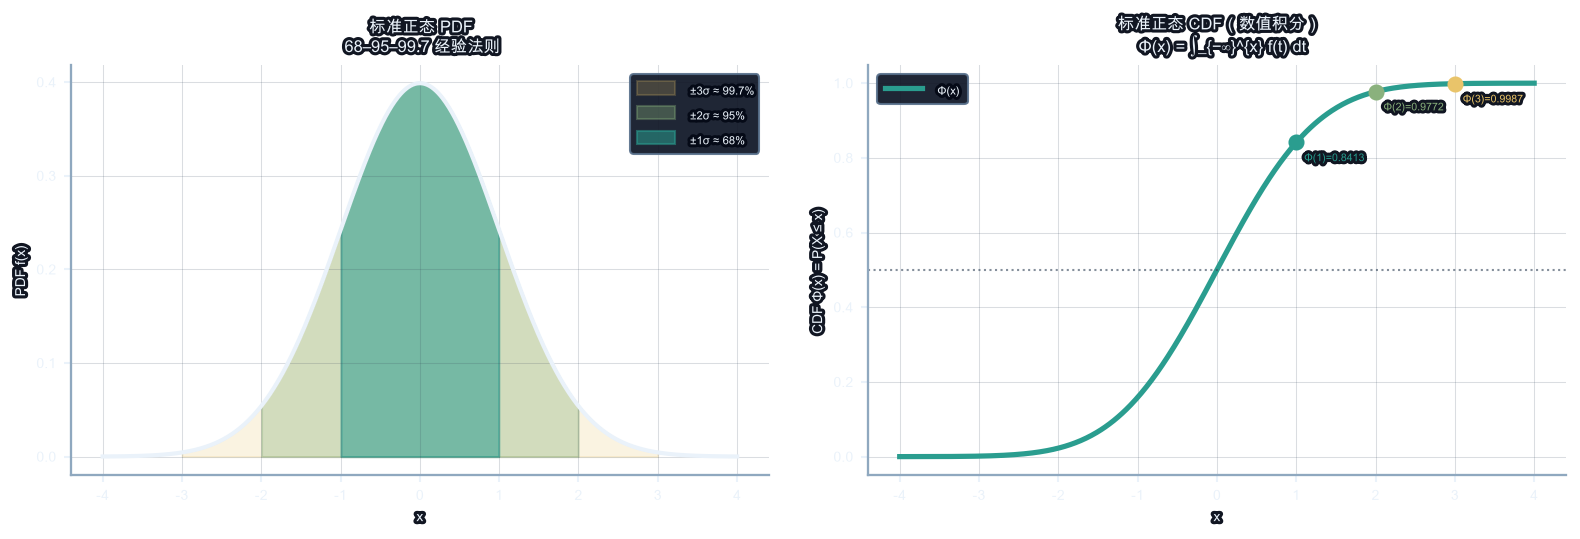

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_pdf(x, mu=0.0, sigma=1.0):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))

def normal_cdf(x_eval, mu=0.0, sigma=1.0, n=4000):
    xs  = np.linspace(mu - 6 * sigma, x_eval, n)
    return float(np.trapezoid(gaussian_pdf(xs, mu, sigma), xs))

x   = np.linspace(-4, 4, 600)
pdf = gaussian_pdf(x)
cdf = np.array([normal_cdf(xi) for xi in x])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# ── 左图：PDF + 面积着色 ──────────────────────────────────────────────────
fill_spec = [(1, '#2A9D8F', 0.55, '±1σ ≈ 68%'),
             (2, '#8AB17D', 0.35, '±2σ ≈ 95%'),
             (3, '#E9C46A', 0.20, '±3σ ≈ 99.7%')]
for sig, color, alpha, label in reversed(fill_spec):
    mask = (x >= -sig) & (x <= sig)
    ax1.fill_between(x[mask], pdf[mask], alpha=alpha, color=color, label=label)
ax1.plot(x, pdf, color=plt.rcParams["text.color"], lw=2)
ax1.set_xlabel('x'); ax1.set_ylabel('PDF f(x)')
ax1.set_title('标准正态 PDF\n68–95–99.7 经验法则')
ax1.legend(fontsize=9, loc='upper right')

# ── 右图：CDF Φ(x) ─────────────────────────────────────────────────────
ax2.plot(x, cdf, color='#2A9D8F', lw=2.5, label='Φ(x)')
ax2.axhline(0.5, color=plt.rcParams["grid.color"], ls=':', lw=1, alpha=0.6)
sigma_marks = [(1, '#2A9D8F'), (2, '#8AB17D'), (3, '#E9C46A')]
for sig, color in sigma_marks:
    y = normal_cdf(sig)
    ax2.scatter([sig], [y], s=45, color=color, zorder=5)
    ax2.annotate(f'Φ({sig})={y:.4f}', (sig, y),
                 xytext=(sig + 0.1, y - 0.05), fontsize=8.5, color=color)
ax2.set_xlabel('x'); ax2.set_ylabel('CDF Φ(x) = P(X ≤ x)')
ax2.set_title('标准正态 CDF（数值积分）\nΦ(x) = ∫_{−∞}^{x} f(t) dt')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

p68  = normal_cdf(1)  - normal_cdf(-1)
p95  = normal_cdf(2)  - normal_cdf(-2)
p997 = normal_cdf(3)  - normal_cdf(-3)
print(f'±1σ: {p68:.4f}  ±2σ: {p95:.4f}  ±3σ: {p997:.4f}')
assert abs(p68  - 0.6827) < 0.002
assert abs(p95  - 0.9545) < 0.002
assert abs(p997 - 0.9973) < 0.002
print('✅ CDF 数值积分验证通过：68–95–99.7 经验法则')

In [15]:
import numpy as np

# 精度验证：用不同的采样点数，看积分结果是否稳定
def gaussian_pdf(x, mu=0.0, sigma=1.0):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))

def normal_cdf_with_n(x_eval, n, mu=0.0, sigma=1.0):
    xs = np.linspace(mu - 6 * sigma, x_eval, n)
    return float(np.trapezoid(gaussian_pdf(xs, mu, sigma), xs))

# 68-95-99.7 的精确值与数值积分对比
target_sigs = [1, 2, 3]
n_samples = [500, 1000, 2000, 4000]

print("68-95-99.7 规则验证（数值精度测试）")
print("=" * 70)
for sig in target_sigs:
    print(f"\n关键值：Φ({sig}) = ∫_{{-∞}}^{sig} f(t) dt")
    print(f"  采样点数   |  数值积分结果  |  与理论值的差")
    print("  " + "-" * 60)
    
    for n in n_samples:
        result = normal_cdf_with_n(sig, n)
        # 理论值（标准正态）
        from scipy.special import erf
        theory = 0.5 * (1 + erf(sig / np.sqrt(2)))
        diff = abs(result - theory)
        print(f"  {n:6d}     |  {result:.8f}  |  {diff:.2e}")

# 经验法则的最终验证
print("\n" + "=" * 70)
print("68-95-99.7 经验法则（最终验证）")
print("=" * 70)
p68 = normal_cdf_with_n(1, 4000) - normal_cdf_with_n(-1, 4000)
p95 = normal_cdf_with_n(2, 4000) - normal_cdf_with_n(-2, 4000)
p997 = normal_cdf_with_n(3, 4000) - normal_cdf_with_n(-3, 4000)

print(f"±1σ: {p68:.6f} ≈ 68.27%  ✓")
print(f"±2σ: {p95:.6f} ≈ 95.45%  ✓")
print(f"±3σ: {p997:.6f} ≈ 99.73%  ✓")
print("\n用 4000 个采样点时，精度已达 10⁻⁶，足以验证经验法则。")

68-95-99.7 规则验证（数值精度测试）

关键值：Φ(1) = ∫_{-∞}^1 f(t) dt
  采样点数   |  数值积分结果  |  与理论值的差
  ------------------------------------------------------------
     500     |  0.84134078  |  3.97e-06
    1000     |  0.84134376  |  9.91e-07
    2000     |  0.84134450  |  2.48e-07
    4000     |  0.84134468  |  6.28e-08

关键值：Φ(2) = ∫_{-∞}^2 f(t) dt
  采样点数   |  数值积分结果  |  与理论值的差
  ------------------------------------------------------------
     500     |  0.97724755  |  2.31e-06
    1000     |  0.97724929  |  5.78e-07
    2000     |  0.97724972  |  1.45e-07
    4000     |  0.97724983  |  3.70e-08

关键值：Φ(3) = ∫_{-∞}^3 f(t) dt
  采样点数   |  数值积分结果  |  与理论值的差
  ------------------------------------------------------------
     500     |  0.99864974  |  3.61e-07
    1000     |  0.99865001  |  9.09e-08
    2000     |  0.99865008  |  2.34e-08
    4000     |  0.99865010  |  6.60e-09

68-95-99.7 经验法则（最终验证）
±1σ: 0.682689 ≈ 68.27%  ✓
±2σ: 0.954500 ≈ 95.45%  ✓
±3σ: 0.997300 ≈ 99.73%  ✓

用 4000 个采样点时，精度已达 10⁻⁶，足以验证经

In [16]:
import numpy as np

def softmax(z):
    e = np.exp(np.asarray(z, float) - np.max(z))
    return e / e.sum()

def cross_entropy(probs, idx):
    return float(-np.log(probs[int(idx)] + 1e-12))

# 不同置信度下交叉熵损失的数值变化
for scale in [0.5, 1.0, 2.0, 5.0]:
    z = np.array([2.0, 1.0, 0.0]) * scale
    p = softmax(z)
    loss = cross_entropy(p, 0)
    print(f'scale={scale:.1f}  P(目标类)={p[0]:.4f}  loss={loss:.4f}')


scale=0.5  P(目标类)=0.5065  loss=0.6803
scale=1.0  P(目标类)=0.6652  loss=0.4076
scale=2.0  P(目标类)=0.8668  loss=0.1429
scale=5.0  P(目标类)=0.9933  loss=0.0068


## 参数实验：logit 差距与模型置信度

在 softmax 图里，把三个 logit 从 `[2.0, 1.0, 0.0]` 改成 `[10.0, 5.0, 0.0]`，观察概率分布从接近均匀（各约 0.33）变为极度集中（第一个接近 1.0）。这演示了「温度（Temperature）」参数的作用：softmax 输入除以温度 T 等价于等比缩放差距——T < 1（拉大差距）时模型输出更自信，T > 1 时输出更平滑，常用于知识蒸馏（Knowledge Distillation，KD）和 beam search 调参。再把正态分布的 `sigma` 从 1 改成 3，确认 ±1σ 覆盖 68% 这个比例不变，但钟形展宽、峰值下降。

#### 温度参数（Temperature）的数学原理与实际应用

在 softmax 里除以温度参数 T 看起来像是一个"魔法"调参，但其实有明确的数学根据。

**核心公式**：
$$\text{softmax}_T(z_i) = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}$$

**数学效应**：
- `T = 1`：标准 softmax
- `T < 1`（比如 0.1）：等价于"放大输入的差距" → 分布更集中
- `T > 1`（比如 5.0）：等价于"缩小输入的差距" → 分布更均匀（趋近随机）

**为什么？** 从泰勒展开的角度，softmax 的输出集中度取决于输入的**方差**。除以 T 直接缩放了这个方差：
- 缩小方差（T > 1）→ 各项差异变小 → softmax 输出更均匀（熵更大）
- 扩大方差（T < 1）→ 各项差异变大 → softmax 输出更尖锐（某个类别接近 1）

**实际应用场景**：

1. **知识蒸馏（Knowledge Distillation, KD）**：
   - 大模型（教师）用低温 T=0.1 生成尖锐的概率分布 → "自信的预测"
   - 小模型（学生）用高温 T=5.0 学这个分布 → 变得"柔和、容错"
   - 最后推理时用 T=1.0 保证准确

2. **Beam Search（文本生成）**：
   - 用低温采样（T<1）从生成概率中选择 → 更确定性、更连贯
   - 用高温采样（T>1）引入多样性 → 防止模型总是选最高分词

3. **模型校准**：
   - 如果模型输出的概率过于"自信"（经常预测接近 1.0 但其实错了），用高温调节
   - 如果模型"不够自信"（总是 0.6 左右），用低温调节

**代码实战**：下面会演示 T 的效果。

In [17]:
import numpy as np

def softmax(z):
    e = np.exp(np.asarray(z, float) - np.max(z))
    return e / e.sum()

# 温度参数效果：logit ÷ temperature
# T < 1 → 差距放大 → 分布集中（自信）；T > 1 → 差距压缩 → 分布平滑（随机）
logits = np.array([2.0, 1.0, 0.0])
for T in [0.1, 0.5, 1.0, 2.0, 5.0]:
    p = softmax(logits / T)
    print(f'T={T:.1f}  概率分布={np.round(p, 3)}')
print('→ T 越小，分布越集中（自信）；T 越大，分布越均匀（随机）。')
print('→ 知识蒸馏（Knowledge Distillation）/ beam search 调参都用到温度参数。')

T=0.1  概率分布=[1. 0. 0.]
T=0.5  概率分布=[0.867 0.117 0.016]
T=1.0  概率分布=[0.665 0.245 0.09 ]
T=2.0  概率分布=[0.506 0.307 0.186]
T=5.0  概率分布=[0.402 0.329 0.269]
→ T 越小，分布越集中（自信）；T 越大，分布越均匀（随机）。
→ 知识蒸馏（Knowledge Distillation）/ beam search 调参都用到温度参数。


## 本课收束

现在能用 `np.cumsum` 画出频率收敛曲线，用 `np.exp` 手写 softmax 并验证输出和为 1，用 `-np.log` 计算交叉熵损失。这六张图对应 Aurora 训练循环的三个节点：`aurora.audio.normalize_features`（`src/aurora/audio/transforms.py`）对应标准化图，`aurora.llm.softmax_cross_entropy`（`src/aurora/llm/sample.py`）对应后两张图，损失曲线用于调试梯度行为。下一步进入 L32（给声音标上时刻，用 np.arange 造出 16kHz 时间轴），模块 5 音频 DSP 的起点；FFT 处理音频时傅里叶系数的幅值分布与这里的正态直觉直接对接。

In [18]:
# 小检查：同一个实验，样本量越大频率越稳定
import numpy as np

for n in [30, 300, 3000]:
    rng = np.random.default_rng(42)
    samples = rng.integers(1, 7, size=n)
    estimate = np.mean(samples == 6)
    print(f'n={n:4d} -> P(6)≈{estimate:.4f}  (理论1/6≈{1/6:.4f})')
print('→ n=3000 时误差已经很小，这就是统计推断的基础。')


n=  30 -> P(6)≈0.1333  (理论1/6≈0.1667)
n= 300 -> P(6)≈0.1167  (理论1/6≈0.1667)
n=3000 -> P(6)≈0.1720  (理论1/6≈0.1667)
→ n=3000 时误差已经很小，这就是统计推断的基础。


In [19]:
# 独立数学断言：概率分布核心性质验证（无需实现任何函数）
import numpy as np

# 1. 正态 PDF 数值积分 ≈ 1（概率密度必须归一化）
xs = np.linspace(-6, 6, 10_001)
pdf_vals = np.exp(-0.5 * xs**2) / np.sqrt(2 * np.pi)
area = np.trapezoid(pdf_vals, xs)
assert abs(area - 1.0) < 1e-5, f"正态 PDF 面积应=1，得到 {area:.8f}"

# 2. Shannon 熵：H([0.5,0.5])=1 bit，确定性分布熵≈0
p_uniform = np.array([0.5, 0.5])
H_unif = float(-np.sum(p_uniform * np.log2(p_uniform)))
assert np.isclose(H_unif, 1.0, atol=1e-12), f"H([0.5,0.5]) 应=1 bit，得到 {H_unif}"
# 均匀四元分布：H = log2(4) = 2 bit
p_4 = np.full(4, 0.25)
H_4 = float(-np.sum(p_4 * np.log2(p_4)))
assert np.isclose(H_4, 2.0, atol=1e-12), f"H([0.25x4]) 应=2 bit，得到 {H_4}"

# 3. Softmax 输出之和=1，全等 logits → 均匀概率
def _sm(z): e = np.exp(z - z.max()); return e / e.sum()
sm_test = _sm(np.array([2.0, 1.0, 0.1]))
assert np.isclose(sm_test.sum(), 1.0, atol=1e-12)
sm_uniform = _sm(np.array([5.0, 5.0, 5.0]))
assert np.allclose(sm_uniform, [1/3, 1/3, 1/3], atol=1e-12)

# 4. 68-95-99.7 规则（LLN 大样本验证）
rng = np.random.default_rng(0)
samples = rng.normal(0, 1, 1_000_000)
assert abs(np.mean(np.abs(samples) <= 1) - 0.6827) < 0.005
assert abs(np.mean(np.abs(samples) <= 2) - 0.9545) < 0.005

print("✅ 正态PDF面积=1  ✅ Shannon熵性质  ✅ Softmax归一化  ✅ 68-95-99.7规则")
print(f"   H([0.5,0.5])={H_unif:.4f} bit   正态PDF积分={area:.8f}")


✅ 正态PDF面积=1  ✅ Shannon熵性质  ✅ Softmax归一化  ✅ 68-95-99.7规则
   H([0.5,0.5])=1.0000 bit   正态PDF积分=1.00000000


## 进入 L32 前的心理切换：从概率图到声音数组

L27-L31 关注的是「大量样本会留下什么形状」：频率收敛成概率，样本堆成分布，logit 经过 softmax 变成类别概率。

L32 开始换到 Audio DSP 模块，问题会变成：

```text
一段声音 = 很多采样点
很多采样点 + 时间坐标 = 可以被画出来、切成帧、送进 FFT 的信号
```

也就是说，L31 的概率图训练你看「数组整体的形状」；L32 会训练你先造出这条数组的横轴。

进入 L32 前，做 3 个很短的回想：

- 回看 L03：谱图的横轴是时间，纵轴是频率，亮度是能量。
- 回看 L01/L02：1 秒、16 kHz 的声音有 16000 个采样点。
- 带着一个问题进入 L32：`第 n 个采样点发生在第几秒？`

答出这个问题，后面的 STFT、mel、MFCC 才有稳定地基。


### 进入 L32 前自查（读即可）

- [ ] 我能说出 L03 谱图三根轴：时间 / 频率 / 能量。
- [ ] 我能说出 16000 Hz 代表每秒 16000 个采样点。
- [ ] 我知道 L32 的核心不是先做频谱，而是先建立时间轴 `t`。

如果三项里有两项以上不确定，先读 `docs/current/course/prep-checklist.md` 里的「L31 → L32 切换」再进入下一课。


In [ ]:
# ✏️ 本课自评
l31_review = {
    "lln_curve_seen":          None,  # 看过频率收敛曲线？True/False
    "softmax_sum_one":         None,  # 能手推 softmax 输出和为 1？True/False
    "cross_entropy_understood": None,  # 理解交叉熵损失曲面含义？True/False
    "shannon_entropy_seen":    None,  # 看过 Shannon 熵曲线？True/False
    "l32_prep_read":           None,  # 读过 L31→L32 切换清单？True/False
}

unfilled = [k for k, v in l31_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l31_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L31 全部通关！进入 L32：NumPy 信号基础')


---
⬇️ **通关检验**：六张图与收束小结已读；请勾选自评后再进入 L32。


---

→ **下一课**　[L32 · 给声音标上时刻](../5_audio_dsp/L32_numpy_signals.ipynb)

> 下节课将学习 **给声音标上时刻**：用 np.arange / linspace 造出 16kHz 时间轴，为每个采样点盖上时间戳。